# Sentiment Analysis on YouTube Comments: "Presiden Prabowo Menjawab"

📌 1. Deskripsi Proyek


*   **Topik**: Analisis sentimen komentar pada video YouTube 'Presiden Prabowo Menjawab' yang diunggah oleh Youtube Najwa Shihab. Video ini membahas wawancara Presiden Indonesia, Prabowo Subianto dengan 7 jurnalis media nasional.
*   **Tujuan**: Mengetahui persepsi publik terhadap video melalui analisis sentimen.
*   **Dataset**: Komentar hasil scraping mandiri dari YouTube, difokuskan pada komentar berbahasa Indonesia.

In [1]:
# 2. Import Library
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import pipeline
from imblearn.over_sampling import SMOTE
from collections import Counter

In [5]:
# 2. Load Dataset
url = "https://raw.githubusercontent.com/hafizhaqolby/sentiment-analysis/5d4ddbf4aac77a5e9d4df8ca7415b8745819027b/youtube_comments_cleaned.csv"
df = pd.read_csv(url)
df = df.dropna(subset=["cleaned_comment"]).reset_index(drop=True)

In [6]:
# 3. EDA Singkat
print("Jumlah komentar:", len(df))
df["cleaned_comment"].sample(5)

Jumlah komentar: 3866


,cleaned_comment
60,karakter kang joged abis wawancara jogedin aja...
2357,lah makanya liat berita yg bner tuh bulog samp...
2147,bang udah bang ini konten nya mba najwa shihab...
1339,mreka lgi bkin template di toktok kaksabar msh...
2340,ah good point mas sorry sebelumnya aku rasa ka...


In [7]:
# 4. Ekstraksi Fitur & Auto-label Sentimen
# Menggunakan model IndoBERT (w11wo/indonesian-roberta-base-sentiment-classifier) untuk pelabelan otomatis
sentiment_pipeline = pipeline("text-classification", model="w11wo/indonesian-roberta-base-sentiment-classifier")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/808k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/467k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu


In [8]:
def get_sentiment(text):
    try:
        result = sentiment_pipeline(text[:512])[0]
        return result['label'].lower()  # positif / negatif / netral
    except:
        return "error"

In [9]:
print("🔎 Melabeli komentar secara otomatis...")
df['label'] = df['cleaned_comment'].apply(get_sentiment)

🔎 Melabeli komentar secara otomatis...


In [10]:
# 5. Vectorization: TF-IDF
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X = vectorizer.fit_transform(df['cleaned_comment'])
y = df['label']

In [11]:
# 6 TF-IDF + SMOTE
print("🔁 Melakukan oversampling dengan SMOTE...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("Distribusi label setelah SMOTE:", Counter(y_resampled))

🔁 Melakukan oversampling dengan SMOTE...
Distribusi label setelah SMOTE: Counter({'positive': 2518, 'neutral': 2518, 'negative': 2518})


In [12]:
# 7 Training Model: TF-IDF + SMOTE + SVM
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
svm_smote = LinearSVC(max_iter=10000)
svm_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = svm_smote.predict(X_test_smote)

Akurasi (TF-IDF + SMOTE + SVM): 0.8841826604897419
              precision    recall  f1-score   support

    negative       0.93      0.77      0.84       504
     neutral       0.88      0.94      0.91       508
    positive       0.85      0.95      0.89       499

    accuracy                           0.88      1511
   macro avg       0.89      0.88      0.88      1511
weighted avg       0.89      0.88      0.88      1511



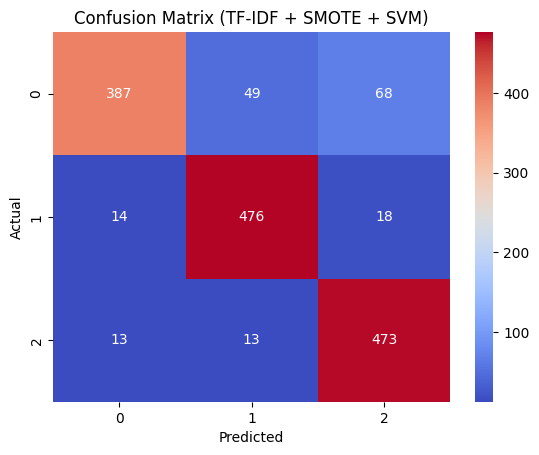

In [13]:
# Evaluasi Model
print("Akurasi (TF-IDF + SMOTE + SVM):", accuracy_score(y_test_smote, y_pred_smote))
print(classification_report(y_test_smote, y_pred_smote))
sns.heatmap(confusion_matrix(y_test_smote, y_pred_smote), annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (TF-IDF + SMOTE + SVM)')
plt.show()

**Kesimpulan** <br>
Model dengan kombinasi TF-IDF, SMOTE, dan SVM menunjukkan performa yang kuat dalam klasifikasi sentimen, mencapai akurasi keseluruhan sebesar 88.4%. Precision, recall, dan F1-score yang tinggi pada semua kelas—terutama neutral (F1-score 0.91) dan positive (recall 0.95)—menunjukkan bahwa SMOTE berhasil mengatasi ketidakseimbangan data dengan baik. Meskipun demikian, kelas negative memiliki recall yang relatif lebih rendah (0.77), mengindikasikan adanya sejumlah false negative yang perlu diperbaiki. Nilai macro average dan weighted average F1-score yang sama (0.88) mencerminkan keseimbangan yang baik antar kelas, sekaligus menegaskan bahwa model ini mampu menangkap pola sentimen secara menyeluruh. Untuk pengembangan selanjutnya, optimasi hyperparameter SVM dan eksperimen dengan teknik ekstraksi fitur tambahan dapat membantu meningkatkan deteksi pada kelas negative serta mengurangi false positive.